Jamie Bly - 300231604
____

For our first analysis, we are going to be exploring the German Credit Risk dataset. This data represents person who have taken out credit with a bank, and can be used by banks or other lenders to determine whether the persion is a good or bad credit risk.

Dataset 1:
German Credit Risk, UCI Learning, Credit Classification
Size: 10 Columns, 1000 Rows
Features
    Age (Numeric)
    Sex (Categorical)
    Job (Categorical)
    Housing (Categorical)
    Savings Account (Categorical)
    Checking Account (Categorical)
    Credit Ammount (Numeric)
    Duration (Numeric)
    Purpose (Categorical)
Redundancies/Missing Values
    I feel that the Savings and Checking Account being binned in this case makes our analysis more difficult, as we are now unable to perform our own binning or establish our own definition of what is "Little, moderate, quite rich or rich"
    The fact that there is only one column for credit per person limits the amount of data analysis we can do, as most people will have multiple debts, for example a mortgage and Car Financing. 


In [109]:
#Import dataset from Kaggle to pandas

# Install dependencies as needed:
%pip install kagglehub[pandas-datasets]
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd

# Set the path to the file you'd like to load
file_path = "german_credit_data.csv"

# Load the latest version
credit_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/german-credit",
  file_path,
)

print("First 5 records:", credit_df.head())

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\200410157.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  credit_df = kagglehub.load_dataset(


Note: you may need to restart the kernel to use updated packages.
First 5 records:    Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  


Insight 1: The large majority of people with debts are between the ages of 20 and 40 years old.

Analsis Type: Boxplot, Histogram and Summary Statistics

How evidence was obtained: Univariate Analysis (Numerical) R1 ---> Histogram and Statiscal Summary. The histogrma is right skewed, meaning that most of the values fall on the right side of the graph, which shows that debts are more likley to be owed by younger people, specifically people between 20 and 40 years old.



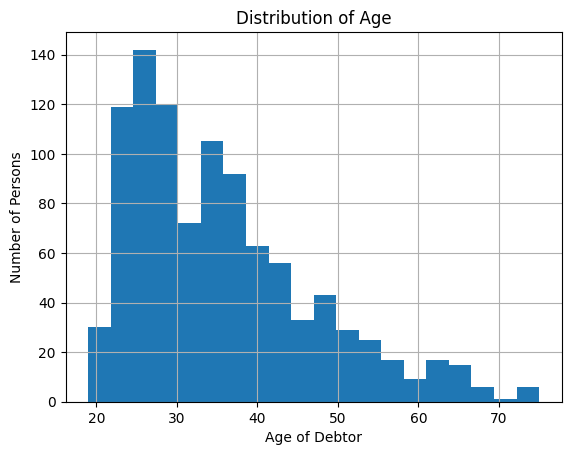

,Age
count,1000.000000
mean,35.546000
std,11.375469
min,19.000000
25%,27.000000
50%,33.000000
75%,42.000000
max,75.000000


In [110]:
credit_df[['Age']].hist(bins=20)

plt.title("Distribution of Age")
plt.xlabel("Age of Debtor")
plt.ylabel("Number of Persons")
plt.show()

credit_df[["Age"]].describe()



Insight 2: There are three prominent purpose in this data: Car, TV/Radio and Equipment/Furniture. These 3 purposes of debt are the vast majority of the debts purposes, comprising more than 75% of all debts.

Analsis Type: Count Plot

How evidence was obtained: Univariate Analysis (Categorical) ---> Count Plot R2. By looking at the count plot graph, and combining the shown percentages, you can see that Car, Radio/TV and Equipment/Furniture hold the vast majority of debts (79.8% of all debts).



C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\2385500606.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


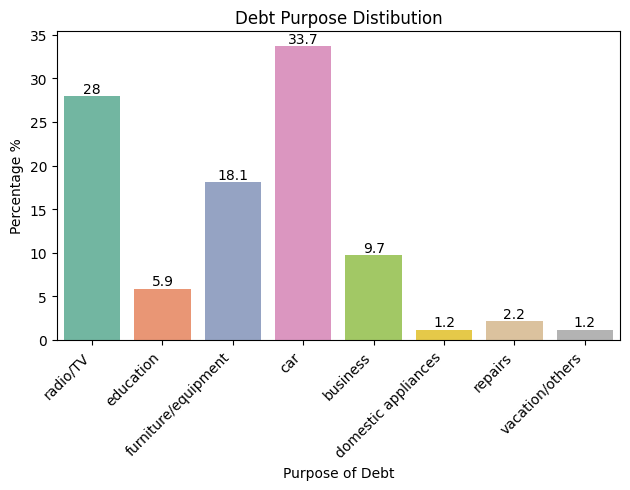

In [111]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())
ax = sns.countplot(x="Purpose", data=credit_df, hue='Purpose', palette=palette, stat='percent')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.ylabel("Percentage %")
plt.xlabel("Purpose of Debt")
plt.title("Debt Purpose Distibution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()

Insight 3: The majority of the debts belong to with persons with skilled jobs. 

Analsis Type: Count Plot

How evidence was obtained: Univariate Analysis (Categorical R3) ---> Count Plot. For this insight, I decided to group the 0 - Unskilled and Non-resident and 1 - Unskilled and Resident, as the designation between Resident and non-resident doesn't provide additional information for analysis to the value that their occupation holds, and their occupations ability to provide for them to repay their debt.

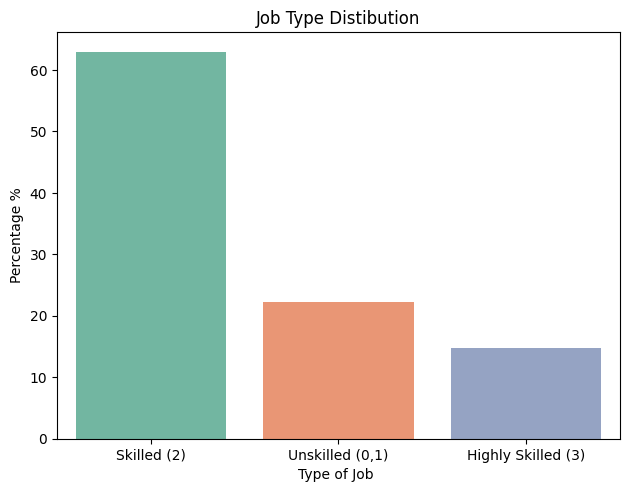

In [112]:
credit_df["Combined_Job"] = credit_df['Job'].map({
    0: "Unskilled (0,1)",
    1: "Unskilled (0,1)",
    2: "Skilled (2)",
    3: "Highly Skilled (3)"
})
palette = sns.color_palette("Set2", credit_df['Combined_Job'].nunique())

ax = sns.countplot(x="Combined_Job", data=credit_df, hue='Combined_Job', palette=palette, stat='percent')

plt.tight_layout()
plt.ylabel("Percentage %")
plt.xlabel("Type of Job ")
plt.title("Job Type Distibution")
plt.show()

Insight 4: From the boxplot and swarmplot, we can see that while debts related to cars or Radio/televisions may be the most popular, of the purposes with uniform distribution (I.E. all but the vacation/other), Business loans hold the highest average credit amount.

Analsis Type: Boxplot and Swarmplot

How evidence was obtained: Bivariate Analysis (Categorical/Numerical R4) ---> Boxplot, Swarmplot. For this insight, by looking at swarmplot, you can see that both car and radio credits are more densly clustered around the bottom of the graph, and become less dense as you ascend the Y-axis. While business loans do decrease as well, it has a less steep decline, and you can see in the boxplot that the average is significantly higher and has a higher floor for the general range.  

c:\Users\djbly\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\4444883.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
c:\Users\djbly\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\djbly\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn

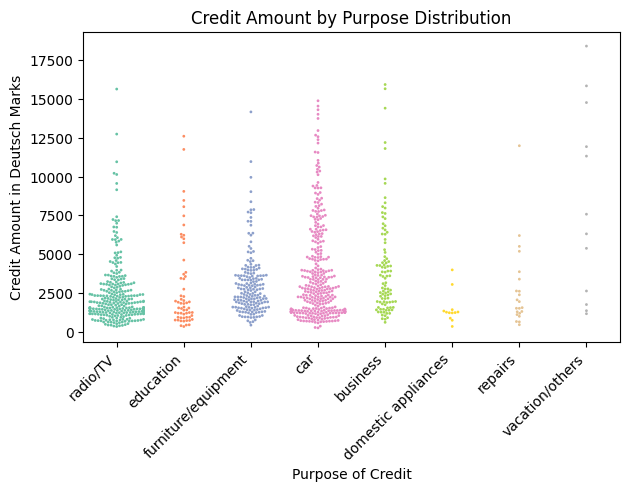

C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\4444883.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bx.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


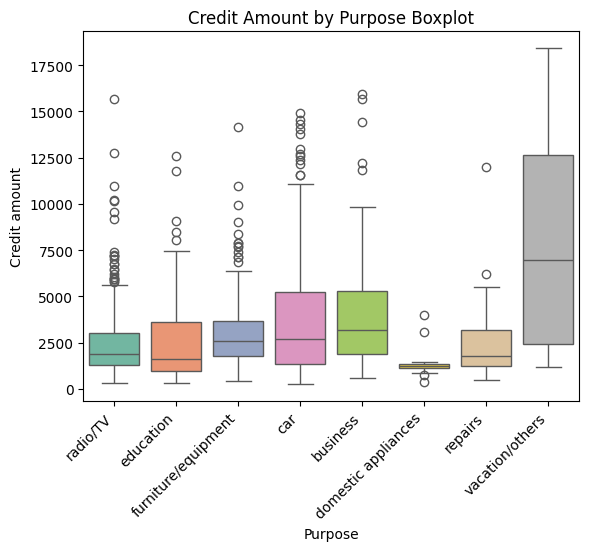

In [113]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())

ax = sns.swarmplot(x="Purpose", data=credit_df, y='Credit amount', hue="Purpose", palette=palette, size=2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.ylabel("Credit Amount in Deutsch Marks")
plt.xlabel("Purpose of Credit")
plt.title("Credit Amount by Purpose Distribution")
plt.show()

bx = sns.boxplot(data=credit_df, x='Purpose', y='Credit amount', hue='Purpose', palette=palette)
bx.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Credit Amount by Purpose Boxplot")
plt.show()

Insight 5: Women debtors are comparatively  more likely to be renting than Male Debtors. 

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R5) ---> Countplot. When looking at the countplot, you can see that when comparing Renters VS Own and Free, that female debtors that are women and renting are a significantly larger percentage of the total than when compared to the male renters.

C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\3957218355.py:3: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.countplot(x="Sex", data=credit_df, hue="Housing", palette=palette)


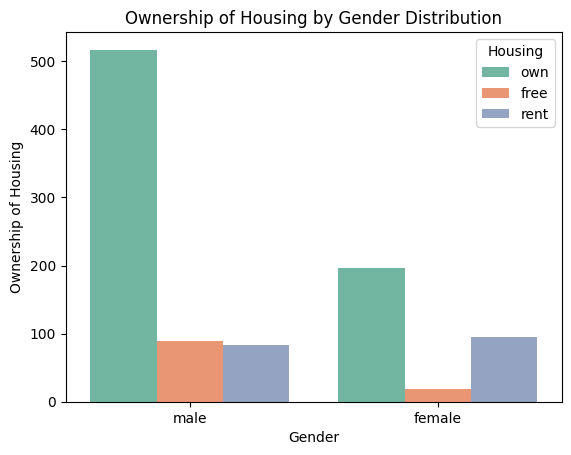

In [114]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())

ax = sns.countplot(x="Sex", data=credit_df, hue="Housing", palette=palette)

plt.ylabel("Ownership of Housing")
plt.xlabel("Gender")
plt.title("Ownership of Housing by Gender Distribution")
plt.show()

Insight 6: Women are comparatively more likely to take on a debt for Education, Furniture/Equipment or domestic appliances than men. 

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R6) ---> Countplot. When looking at the countplot, you can see that when comparing the three mentioned categories (Education, Furniutre/Equipment and Domestic appliances), that women hold a comparatively higher number of debts than other purposes.These category have women accounting for well over 40% of all debts, despite having an overall population of around 30%.

C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\1811168540.py:3: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.countplot(x="Purpose", data=credit_df, hue="Sex", palette=palette, order=credit_df['Purpose'].value_counts().index, hue_order=['male', 'female'], stat='percent')
C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\1811168540.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


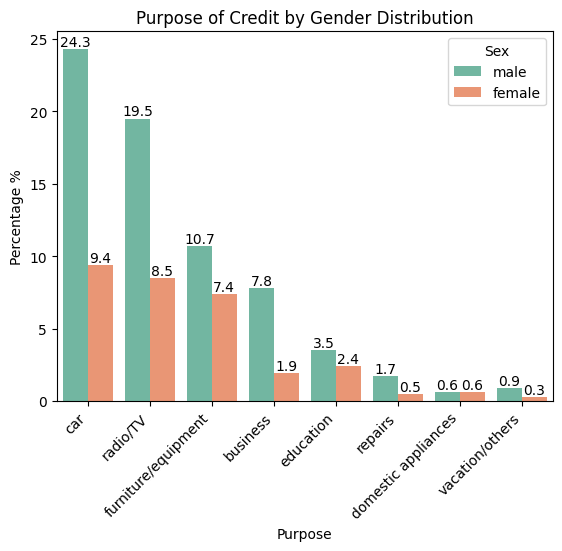

In [115]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())

ax = sns.countplot(x="Purpose", data=credit_df, hue="Sex", palette=palette, order=credit_df['Purpose'].value_counts().index, hue_order=['male', 'female'], stat='percent')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel("Percentage %")
plt.xlabel("Purpose")
plt.title("Purpose of Credit by Gender Distribution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()



Insight 7: The younger that a debtor is, the higher the likelihood that they have an Skilled Job is, and the older they are, the more likely they are to be highly skilled.

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Numeric R7) ---> Countplot. First we split the age into bins using pandas cut function to split it into 8 differnet bins, then we show the binned ages with the previously created Combined_Job as the hue.

C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\2642576477.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.countplot(x="Binned_Age", data=credit_df, hue="Combined_Job", palette=palette, stat='percent', hue_order=['Unskilled (0,1)', 'Skilled (2)', 'Highly Skilled (3)'])
C:\Users\djbly\AppData\Local\Temp\ipykernel_39700\2642576477.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


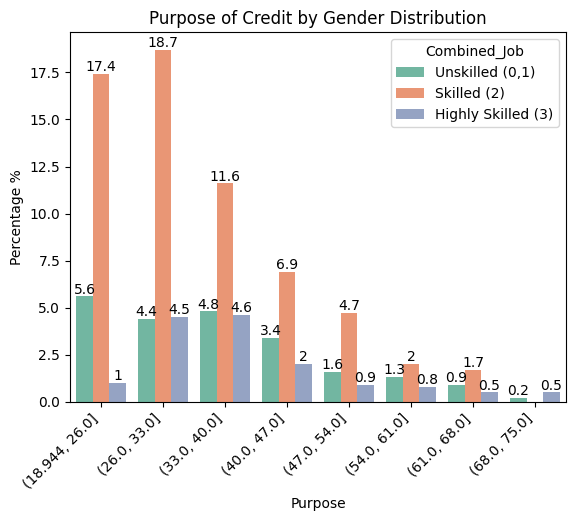

In [124]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())

credit_df['Binned_Age'] = pd.cut(credit_df['Age'], 8)

ax = sns.countplot(x="Binned_Age", data=credit_df, hue="Combined_Job", palette=palette, stat='percent', hue_order=['Unskilled (0,1)', 'Skilled (2)', 'Highly Skilled (3)'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel("Percentage %")
plt.xlabel("Purpose")
plt.title("Purpose of Credit by Gender Distribution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()


Insight 8: There is a direct correlation between the duration of the debt and the Credit amount owed.

Analsis Type: Scatterplot

How evidence was obtained: Bivariate Analysis (Numberical/Numerical R8) ---> A scatterplot of Duration vs Credit Amount that shows a general upwards trend, which demonstrates a moderate, positive correlation between the Amount owed and the duration.

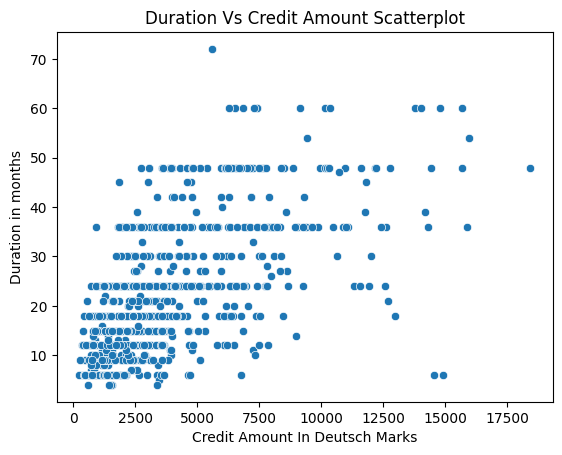

In [ ]:
ax = sns.scatterplot(x="Credit amount", data=credit_df, y="Duration")

plt.ylabel("Duration in months")
plt.xlabel("Credit Amount In Deutsch Marks")
plt.title("Duration Vs Credit Amount Scatterplot")
    
plt.show()


Insight 9: Debtors with High Skilled jobs have a higher debt duration on average than other jobs

Analsis Type: Boxplot

How evidence was obtained: Bivariate Analysis (Categorical/Numerical) ---> A boxplot of Duration by the debtors job type.

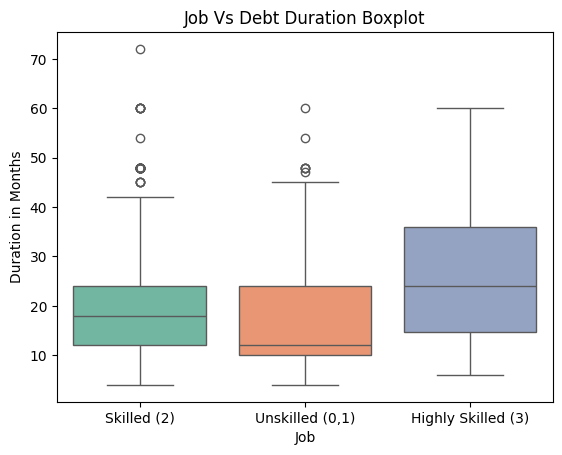

In [156]:
palette = sns.color_palette("Set2", credit_df['Combined_Job'].nunique())
sns.boxplot(x="Combined_Job", y="Duration", hue="Combined_Job", data=credit_df, palette=palette)

plt.title("Job Vs Debt Duration Boxplot")
plt.xlabel("Job")
plt.ylabel("Duration in Months")
plt.show()

Insight 10: There is a negligible correlation between Age and the following three numeric values (Job, Duration, Credit Amount)

Analsis Type: Heatmap

How evidence was obtained: Bivariate Analysis (Numerical/Numerical) ---> A heatmap of showing the correlations between Credit amount, job, duration and age shows that while there is a either a weak or moderate correlation between credit amount, job and duration, there is no correlation between any of those 3 and Age, as they are all approximately 0.

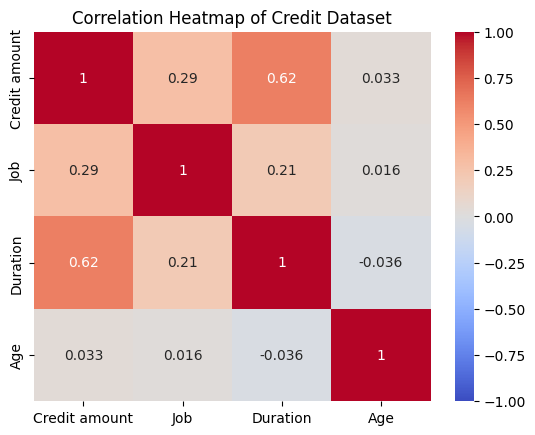

In [159]:
cols = ["Credit amount", "Job", "Duration", "Age"]
corr = credit_df[cols].corr()

sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap of Credit Dataset")
plt.show()